In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n-1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))             # Right-hand side vector
    return A, B, C, D

In [3]:
# Example data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 2, 5, 6, 2])

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)

Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-24.  24. -12. -30.]


In [4]:
import numpy as np
def thomas_algorithm(a1, b1, c1, d1):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    a = a1.copy()
    b = b1.copy()
    c = c1.copy()
    d = d1.copy()
    
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [5]:
M = thomas_algorithm(A[1:], B, C[:-1], D)
M = np.insert(M, 0, 0)
M = np.insert(M, len(M), 0)
print("Solution:", M)

Solution: [ 0.         -8.23923445  8.9569378  -3.58851675 -6.60287081  0.        ]


*Used AI to figure out how to convert the second derivitive, M, array to get spline equations for each interval, the equation it gave will be used in the spline graphing function below (this equation is used to complete step 4 of the homework)

In [17]:
def evaluate_spline(x, y, M):
    for i in range(len(x)-1):
        h = x[i+1] - x[i]
        x_spline = np.linspace(x[i], x[i+1], 100)
        y_spline = ((M[i] / (6 * h)) * (x[i+1] - x_spline)**3) + ((M[i+1] / (6 * h)) * (x_spline - x[i])**3) + ((y[i] / h - (M[i] * h) / 6) * (x[i+1] - x_spline)) + ((y[i+1] / h - (M[i+1] * h) / 6) * (x_spline - x[i]))     #Equation from AI
        plt.plot(x_spline, y_spline)
        plt.scatter(x, y)
    plt.show()
    return 

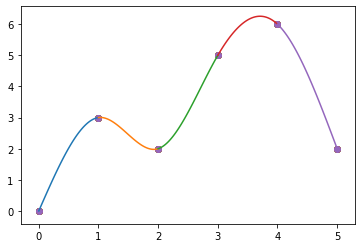

In [18]:
evaluate_spline(x, y, M)